# Lesson 1: Introduction to Multi-Omics Analysis

**Integrating Genomics and Transcriptomics for Complex Disease Studies**

This notebook accompanies the introductory slides and provides hands-on examples for each concept covered in the lecture.

---

## Lesson Overview

1. **Linear Algebra Foundations** - Vectors, matrices, decompositions
2. **Multi-Omics Data & ASD Dataset** - Genomics, transcriptomics, and our course dataset
3. **Data Preprocessing & Quality Control** - Loading, validation, and QC
4. **Key Theoretical Concepts** - Why integration matters

---
## Setup and Imports

In [1]:
# Core libraries
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.linalg import svd
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


---
# Section 1: Linear Algebra Foundations

All multi-omics methods rely on linear algebra. Let's explore the key concepts with biological examples.

## 1.1 Vectors and Matrices

A **vector** represents a single sample's measurements (e.g., one patient's gene expression).
A **matrix** stacks multiple samples together.

In [2]:
# Example: A gene expression vector for one patient (5 genes)
patient_1 = np.array([10.2, 5.5, 8.7, 2.1, 15.3])
gene_names = ['SHANK3', 'CHD8', 'MECP2', 'NRXN1', 'PTEN']

print("Patient 1 expression vector:")
for gene, expr in zip(gene_names, patient_1):
    print(f"  {gene}: {expr}")

print(f"\nVector dimension: {patient_1.shape[0]} (5 genes)")
print(f"Vector magnitude (L2 norm): {np.linalg.norm(patient_1):.2f}")

Patient 1 expression vector:
  SHANK3: 10.2
  CHD8: 5.5
  MECP2: 8.7
  NRXN1: 2.1
  PTEN: 15.3

Vector dimension: 5 (5 genes)
Vector magnitude (L2 norm): 21.18


In [3]:
# Example: Expression matrix (5 genes × 3 patients)
expression_matrix = np.array([
    [10.2, 12.5, 8.9],   # SHANK3
    [5.5, 4.2, 6.1],     # CHD8
    [8.7, 9.1, 7.5],     # MECP2
    [2.1, 1.8, 3.2],     # NRXN1
    [15.3, 14.7, 16.2]   # PTEN
])

print("Expression Matrix (genes × samples):")
print(f"Shape: {expression_matrix.shape} = (5 genes × 3 samples)")
print("\nMatrix:")
df = pl.DataFrame({
    'Patient_1': expression_matrix[:, 0],
    'Patient_2': expression_matrix[:, 1],
    'Patient_3': expression_matrix[:, 2]
})
df = df.with_columns(pl.Series('gene', gene_names))
df = df.select(['gene', 'Patient_1', 'Patient_2', 'Patient_3'])
print(df)

Expression Matrix (genes × samples):
Shape: (5, 3) = (5 genes × 3 samples)

Matrix:
shape: (5, 4)
┌────────┬───────────┬───────────┬───────────┐
│ gene   ┆ Patient_1 ┆ Patient_2 ┆ Patient_3 │
│ ---    ┆ ---       ┆ ---       ┆ ---       │
│ str    ┆ f64       ┆ f64       ┆ f64       │
╞════════╪═══════════╪═══════════╪═══════════╡
│ SHANK3 ┆ 10.2      ┆ 12.5      ┆ 8.9       │
│ CHD8   ┆ 5.5       ┆ 4.2       ┆ 6.1       │
│ MECP2  ┆ 8.7       ┆ 9.1       ┆ 7.5       │
│ NRXN1  ┆ 2.1       ┆ 1.8       ┆ 3.2       │
│ PTEN   ┆ 15.3      ┆ 14.7      ┆ 16.2      │
└────────┴───────────┴───────────┴───────────┘


### Vector Operations

In [4]:
# Dot product: measure similarity between two patients
patient_2 = np.array([12.5, 4.2, 9.1, 1.8, 14.7])

dot_product = np.dot(patient_1, patient_2)
cosine_similarity = dot_product / (np.linalg.norm(patient_1) * np.linalg.norm(patient_2))

print(f"Dot product (Patient 1 · Patient 2): {dot_product:.2f}")
print(f"Cosine similarity: {cosine_similarity:.4f}")
print("\nInterpretation: High cosine similarity (close to 1) means similar expression patterns")

Dot product (Patient 1 · Patient 2): 458.46
Cosine similarity: 0.9922

Interpretation: High cosine similarity (close to 1) means similar expression patterns


## 1.2 Matrix Operations

In [5]:
# Transpose: Flip rows and columns
print("Original matrix shape:", expression_matrix.shape)
transposed = expression_matrix.T
print("Transposed matrix shape:", transposed.shape)

print("\nOriginal: genes × samples")
print("Transposed: samples × genes")
print("\nTransposed matrix:")
df_t = pl.DataFrame({
    gene: transposed[:, i] for i, gene in enumerate(gene_names)
})
df_t = df_t.with_columns(pl.Series('sample', ['Patient_1', 'Patient_2', 'Patient_3']))
df_t = df_t.select(['sample'] + gene_names)
print(df_t)

Original matrix shape: (5, 3)
Transposed matrix shape: (3, 5)

Original: genes × samples
Transposed: samples × genes

Transposed matrix:
shape: (3, 6)
┌───────────┬────────┬──────┬───────┬───────┬──────┐
│ sample    ┆ SHANK3 ┆ CHD8 ┆ MECP2 ┆ NRXN1 ┆ PTEN │
│ ---       ┆ ---    ┆ ---  ┆ ---   ┆ ---   ┆ ---  │
│ str       ┆ f64    ┆ f64  ┆ f64   ┆ f64   ┆ f64  │
╞═══════════╪════════╪══════╪═══════╪═══════╪══════╡
│ Patient_1 ┆ 10.2   ┆ 5.5  ┆ 8.7   ┆ 2.1   ┆ 15.3 │
│ Patient_2 ┆ 12.5   ┆ 4.2  ┆ 9.1   ┆ 1.8   ┆ 14.7 │
│ Patient_3 ┆ 8.9    ┆ 6.1  ┆ 7.5   ┆ 3.2   ┆ 16.2 │
└───────────┴────────┴──────┴───────┴───────┴──────┘


In [6]:
# Matrix multiplication: Project data onto new dimensions
# Example: 3 patients × 5 genes projected onto 2 components

samples_matrix = expression_matrix.T  # (3 samples × 5 genes)
projection_matrix = np.array([
    [0.5, 0.3],   # Gene 1 loadings on 2 components
    [0.2, 0.6],   # Gene 2
    [0.4, 0.1],   # Gene 3
    [0.1, 0.5],   # Gene 4
    [0.3, 0.2]    # Gene 5
])

print(f"Samples matrix: {samples_matrix.shape}")
print(f"Projection matrix: {projection_matrix.shape}")

projected = samples_matrix @ projection_matrix
print(f"Result: {projected.shape}")
print("\nThis is how PCA projects high-dimensional data onto principal components!")

Samples matrix: (3, 5)
Projection matrix: (5, 2)
Result: (3, 2)

This is how PCA projects high-dimensional data onto principal components!


## 1.3 Covariance and Correlation

These matrices capture relationships between genes - essential for WGCNA and clustering.

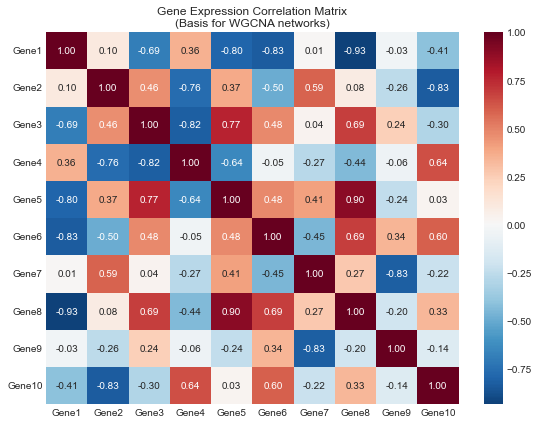

High positive correlation (red): Genes that tend to be co-expressed
High negative correlation (blue): Genes with opposite expression patterns


In [7]:
# Create a larger example dataset
np.random.seed(42)
n_samples = 50
n_genes = 10

# Simulate correlated gene expression (some genes co-expressed)
base = np.random.randn(n_samples, 3)  # 3 latent factors
loadings = np.random.randn(3, n_genes)
noise = np.random.randn(n_samples, n_genes) * 0.3
simulated_expr = base @ loadings + noise

# Calculate correlation matrix
correlation_matrix = np.corrcoef(simulated_expr.T)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            xticklabels=[f'Gene{i+1}' for i in range(n_genes)],
            yticklabels=[f'Gene{i+1}' for i in range(n_genes)])
plt.title('Gene Expression Correlation Matrix\n(Basis for WGCNA networks)')
plt.tight_layout()
plt.show()

print("High positive correlation (red): Genes that tend to be co-expressed")
print("High negative correlation (blue): Genes with opposite expression patterns")

## 1.4 Singular Value Decomposition (SVD)

SVD is the foundation of PCA and MOFA2. It decomposes data into meaningful components.

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.093124,-0.014163,-0.142537,0.067456,0.115911,0.154396,-0.146964,0.032146,0.281181,0.045892
0.013459,0.01998,-0.276163,-0.073389,0.002012,0.123056,0.00309,-0.012518,-0.03182,-0.048219
-0.020575,0.12476,-0.344065,0.026759,-0.11934,-0.26894,-0.034518,-0.260839,-0.200056,-0.099794
0.054817,-0.033218,-0.086228,-0.121341,-0.000714,-0.140032,-0.02682,-0.110533,0.153506,-0.062184
0.267406,-0.231049,0.027285,-0.046042,0.318959,-0.01446,-0.243038,-0.101563,-0.20676,0.030449
…,…,…,…,…,…,…,…,…,…
0.048581,-0.051403,-0.326434,-0.036363,-0.306017,0.067756,-0.050038,0.087709,-0.046966,0.146879
-0.023268,-0.151785,-0.130989,-0.260672,-0.168648,0.136544,0.100996,-0.182113,-0.146822,-0.019811
-0.001938,-0.184534,-0.263868,-0.118894,0.28721,0.028187,0.292896,-0.140139,-0.141117,0.035429


column_0
f64
25.307269
21.802921
13.237834
2.721111
2.334869
2.300899
2.109942
1.886814
1.730249


column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.313732,0.224678,-0.066812,-0.060094,-0.134478,-0.274135,0.064114,-0.476257,0.018822,-0.720067
-0.258318,0.317891,0.388878,-0.274952,0.292203,0.061533,0.234026,0.523545,-0.040143,-0.430981
-0.137458,-0.143254,0.296545,-0.100813,-0.056211,0.292739,-0.713189,-0.084535,0.457517,-0.220271
-0.072033,-0.437111,-0.091748,0.212129,-0.210897,-0.057857,0.468017,0.211088,0.632545,-0.196959
0.595891,-0.375411,0.063669,-0.14836,0.555455,0.380463,0.136668,-0.059519,-0.008882,-0.048312
-0.125896,-0.185559,-0.737156,-0.50413,-0.040779,0.073278,-0.174057,0.248384,-0.105282,-0.205096
-0.005661,0.422179,-0.380141,0.258466,0.585366,-0.188101,-0.142136,0.024902,0.451476,0.08793
-0.657899,-0.298629,-0.026786,0.08882,0.383605,0.061032,0.150556,-0.495947,-0.171797,-0.142691
0.012967,0.122764,-0.215023,0.646137,-0.111142,0.55571,-0.06199,0.179049,-0.258678,-0.31153


Original data shape: (50, 10)

SVD Components:
  U (sample loadings): (50, 10)
  S (singular values): (10,)
  V^T (gene loadings): (10, 10)


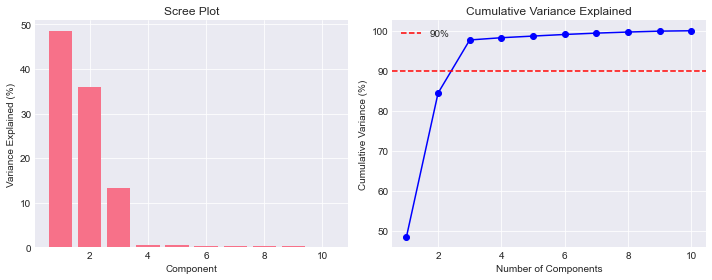


First 3 components explain 97.7% of variance
This is why dimensionality reduction works - most information is in a few components!


In [8]:
# Perform SVD on our simulated expression data
# X = U × Σ × V^T

# Center the data first
X_centered = simulated_expr - simulated_expr.mean(axis=0)

# SVD decomposition
U, S, Vt = svd(X_centered, full_matrices=False)

display(pl.DataFrame(U))
display(pl.DataFrame(S))
display(pl.DataFrame(Vt))
print(f"Original data shape: {X_centered.shape}")
print(f"\nSVD Components:")
print(f"  U (sample loadings): {U.shape}")
print(f"  S (singular values): {S.shape}")
print(f"  V^T (gene loadings): {Vt.shape}")

# Variance explained by each component
variance_explained = (S**2) / np.sum(S**2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(S)+1), variance_explained * 100)
plt.xlabel('Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(S)+1), np.cumsum(variance_explained) * 100, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('Cumulative Variance Explained')
plt.axhline(90, color='r', linestyle='--', label='90%')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFirst 3 components explain {variance_explained[:3].sum()*100:.1f}% of variance")
print("This is why dimensionality reduction works - most information is in a few components!")

## 1.5 Distance Metrics and Similarity Measures

Understanding how to measure relationships between samples is crucial for clustering, classification, and data integration.

### 1.5.1 Z-Score Standardization

**Z-scores** tell us how many standard deviations a value is from the mean.

Formula: `z = (x - μ) / σ`

This is essential for:
- Comparing features on different scales
- Removing the effect of magnitude differences
- Preparing data for distance-based methods

In [9]:
# Example: Three patients with different gene expression levels
patient_A = np.array([100, 250, 80, 500])  # High expression
patient_B = np.array([95, 245, 78, 505])   # Similar to A
patient_C = np.array([50, 120, 40, 250])   # Low expression (half of A)
gene_names_short = ['Gene1', 'Gene2', 'Gene3', 'Gene4']

# Stack into matrix (samples × genes)
X = np.array([patient_A, patient_B, patient_C])

print("Original Expression Values:")
print("="*60)
for i, (name, patient) in enumerate(zip(['Patient_A', 'Patient_B', 'Patient_C'], X)):
    print(f"{name}: {patient}")

# Standardize (Z-score normalization)
# For each gene: subtract mean and divide by std
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0)

print("\nZ-Score Standardized Values:")
print("="*60)
for i, (name, patient) in enumerate(zip(['Patient_A', 'Patient_B', 'Patient_C'], X_standardized)):
    print(f"{name}: {np.round(patient, 2)}")

print("\nInterpretation:")
print("  • Mean = 0, Std = 1 for each gene")
print("  • Positive z-score: above average expression")
print("  • Negative z-score: below average expression")
print("  • |z| > 2: more than 2 standard deviations from mean")

Original Expression Values:
Patient_A: [100 250  80 500]
Patient_B: [ 95 245  78 505]
Patient_C: [ 50 120  40 250]

Z-Score Standardized Values:
Patient_A: [0.82 0.75 0.76 0.69]
Patient_B: [0.59 0.67 0.65 0.73]
Patient_C: [-1.41 -1.41 -1.41 -1.41]

Interpretation:
  • Mean = 0, Std = 1 for each gene
  • Positive z-score: above average expression
  • Negative z-score: below average expression
  • |z| > 2: more than 2 standard deviations from mean


### 1.5.2 Distance Metrics

Distance metrics quantify how **different** two samples are.

#### Euclidean Distance

**Straight-line distance** between two points.

Formula: `d = √(Σ(x_i - y_i)²)`

- Most common distance metric
- Sensitive to scale (use standardization!)
- Sensitive to outliers (squared differences)

In [10]:
# Euclidean distance between patients
def euclidean_distance(v1, v2):
    return np.sqrt(np.sum((v1 - v2)**2))

print("Euclidean Distances (Original Scale):")
print("="*60)
print(f"Patient A ↔ B: {euclidean_distance(patient_A, patient_B):.2f}")
print(f"Patient A ↔ C: {euclidean_distance(patient_A, patient_C):.2f}")
print(f"Patient B ↔ C: {euclidean_distance(patient_B, patient_C):.2f}")

print("\nEuclidean Distances (Standardized):")
print("="*60)
print(f"Patient A ↔ B: {euclidean_distance(X_standardized[0], X_standardized[1]):.2f}")
print(f"Patient A ↔ C: {euclidean_distance(X_standardized[0], X_standardized[2]):.2f}")
print(f"Patient B ↔ C: {euclidean_distance(X_standardized[1], X_standardized[2]):.2f}")

print("\nNote: Standardization changes the distances!")
print("      A and B are now closer because they have similar PATTERNS")

Euclidean Distances (Original Scale):
Patient A ↔ B: 8.89
Patient A ↔ C: 288.96
Patient B ↔ C: 290.03

Euclidean Distances (Standardized):
Patient A ↔ B: 0.26
Patient A ↔ C: 4.33
Patient B ↔ C: 4.14

Note: Standardization changes the distances!
      A and B are now closer because they have similar PATTERNS


#### Manhattan Distance (L1 Distance)

**Sum of absolute differences** (like walking on a grid).

Formula: `d = Σ|x_i - y_i|`

- More robust to outliers than Euclidean
- Used in LASSO regression
- Useful when features are not correlated

Manhattan Distances (Standardized):
Patient A ↔ B: 0.46
Patient A ↔ C: 8.66
Patient B ↔ C: 8.29

WHY IS MANHATTAN MORE ROBUST?

Scenario: 100 genes, Patient F has 5 genes with 2.5× expression
  Patient E (normal): mean=98.4, std=13.6
  Patient F (outliers): mean=106.1, std=37.2

Euclidean distance: 345.00
  Contribution from 5 outlier genes: 345.00
  Fraction from outliers: 100.0%

Manhattan distance: 770.04
  Contribution from 5 outlier genes: 770.04
  Fraction from outliers: 100.0%

✓ Key Insight:
  • Euclidean: Outliers contribute 100.0% (SQUARED amplification)
  • Manhattan: Outliers contribute 100.0% (LINEAR, more robust)
  • In Euclidean, 5% of genes contribute 100.0% of distance!
  • This is why Manhattan is preferred when outliers are expected


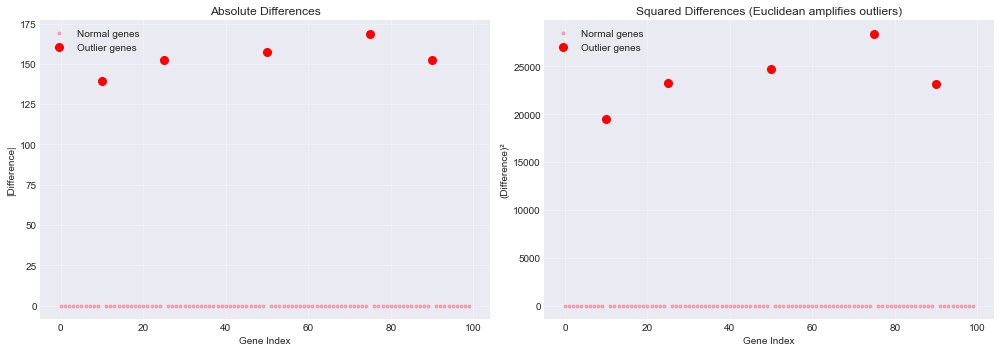


Conclusion: Manhattan is robust because it doesn't SQUARE differences
When you have moderate outliers across many dimensions, this matters!


In [11]:
# Manhattan distance between patients
def manhattan_distance(v1, v2):
    return np.sum(np.abs(v1 - v2))

print("Manhattan Distances (Standardized):")
print("="*60)
print(f"Patient A ↔ B: {manhattan_distance(X_standardized[0], X_standardized[1]):.2f}")
print(f"Patient A ↔ C: {manhattan_distance(X_standardized[0], X_standardized[2]):.2f}")
print(f"Patient B ↔ C: {manhattan_distance(X_standardized[1], X_standardized[2]):.2f}")

# Better demonstration: Multiple moderate outliers in high dimensions
print("\n" + "="*70)
print("WHY IS MANHATTAN MORE ROBUST?")
print("="*70)

# Create two patients with similar baseline + different outlier scenarios
np.random.seed(42)
n_genes = 100

# Patient E: Normal expression
patient_E = np.random.normal(100, 15, n_genes)

# Patient F: Similar to E but with 5 moderate outliers (2-3x higher)
patient_F = patient_E.copy()
outlier_idx = [10, 25, 50, 75, 90]
patient_F[outlier_idx] = patient_E[outlier_idx] * 2.5  # 2.5x higher

print(f"\nScenario: 100 genes, Patient F has 5 genes with 2.5× expression")
print(f"  Patient E (normal): mean={patient_E.mean():.1f}, std={patient_E.std():.1f}")
print(f"  Patient F (outliers): mean={patient_F.mean():.1f}, std={patient_F.std():.1f}")

# Calculate both distances
euc_dist = euclidean_distance(patient_E, patient_F)
man_dist = manhattan_distance(patient_E, patient_F)

# Break down contributions
diff = np.abs(patient_E - patient_F)
diff_squared = (patient_E - patient_F)**2

# Contribution from outlier genes
outlier_contribution_euclidean = np.sqrt(np.sum(diff_squared[outlier_idx]))
total_euclidean = euc_dist
outlier_fraction_euclidean = outlier_contribution_euclidean / total_euclidean

outlier_contribution_manhattan = np.sum(diff[outlier_idx])
total_manhattan = man_dist
outlier_fraction_manhattan = outlier_contribution_manhattan / total_manhattan

print(f"\nEuclidean distance: {euc_dist:.2f}")
print(f"  Contribution from 5 outlier genes: {outlier_contribution_euclidean:.2f}")
print(f"  Fraction from outliers: {outlier_fraction_euclidean*100:.1f}%")

print(f"\nManhattan distance: {man_dist:.2f}")
print(f"  Contribution from 5 outlier genes: {outlier_contribution_manhattan:.2f}")
print(f"  Fraction from outliers: {outlier_fraction_manhattan*100:.1f}%")

print(f"\n✓ Key Insight:")
print(f"  • Euclidean: Outliers contribute {outlier_fraction_euclidean*100:.1f}% (SQUARED amplification)")
print(f"  • Manhattan: Outliers contribute {outlier_fraction_manhattan*100:.1f}% (LINEAR, more robust)")
print(f"  • In Euclidean, {5/100*100:.0f}% of genes contribute {outlier_fraction_euclidean*100:.1f}% of distance!")
print(f"  • This is why Manhattan is preferred when outliers are expected")

# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot differences
axes[0].plot(diff, 'o', alpha=0.5, markersize=3, label='Normal genes')
axes[0].plot(outlier_idx, diff[outlier_idx], 'ro', markersize=8, label='Outlier genes')
axes[0].set_xlabel('Gene Index')
axes[0].set_ylabel('|Difference|')
axes[0].set_title('Absolute Differences')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot squared differences (Euclidean weights)
axes[1].plot(diff_squared, 'o', alpha=0.5, markersize=3, label='Normal genes')
axes[1].plot(outlier_idx, diff_squared[outlier_idx], 'ro', markersize=8, label='Outlier genes')
axes[1].set_xlabel('Gene Index')
axes[1].set_ylabel('(Difference)²')
axes[1].set_title('Squared Differences (Euclidean amplifies outliers)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Conclusion: Manhattan is robust because it doesn't SQUARE differences")
print("When you have moderate outliers across many dimensions, this matters!")
print("="*70)

### 1.5.3 Similarity Metrics

Similarity metrics quantify how **similar** two samples are (higher = more similar).

#### Cosine Similarity

**Measures the angle** between two vectors (ignores magnitude).

Formula: `cosine_sim = (A · B) / (||A|| × ||B||)`

- Range: [-1, 1] (1 = identical direction, -1 = opposite)
- **Ignores magnitude** - only cares about pattern
- Perfect for expression patterns (fold-changes)
- Used in text mining, recommender systems

In [12]:
# Cosine similarity
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("Cosine Similarity (Original Scale):")
print("="*60)
print(f"Patient A ↔ B: {cosine_similarity(patient_A, patient_B):.4f}")
print(f"Patient A ↔ C: {cosine_similarity(patient_A, patient_C):.4f}")
print(f"Patient B ↔ C: {cosine_similarity(patient_B, patient_C):.4f}")

print("\nKey Insight:")
print("  • A and C have perfect cosine similarity (1.0000)")
print("  • Even though C has HALF the expression of A")
print("  • They have the SAME PATTERN (C = 0.5 × A)")
print("  • Cosine similarity ignores magnitude!")

# Demonstrate with a different pattern
patient_D = np.array([500, 80, 250, 100])  # Different pattern

print("\nPatient D (different pattern):")
print(f"  Values: {patient_D}")
print(f"  Cosine similarity (A ↔ D): {cosine_similarity(patient_A, patient_D):.4f}")
print("  Lower similarity because of different pattern!")

Cosine Similarity (Original Scale):
Patient A ↔ B: 0.9999
Patient A ↔ C: 0.9999
Patient B ↔ C: 0.9999

Key Insight:
  • A and C have perfect cosine similarity (1.0000)
  • Even though C has HALF the expression of A
  • They have the SAME PATTERN (C = 0.5 × A)
  • Cosine similarity ignores magnitude!

Patient D (different pattern):
  Values: [500  80 250 100]
  Cosine similarity (A ↔ D): 0.4257
  Lower similarity because of different pattern!


#### Pearson Correlation

**Cosine similarity on centered data** (subtract mean first).

Formula: `r = cov(X,Y) / (σ_X × σ_Y)`

Or equivalently: `r = cosine_similarity(X - X̄, Y - Ȳ)`

- Range: [-1, 1]
- Measures linear relationship
- Used in WGCNA, correlation networks
- **Invariant to scale AND shift**

In [13]:
# Pearson correlation
def pearson_correlation(v1, v2):
    # Method 1: Using numpy's corrcoef
    return np.corrcoef(v1, v2)[0, 1]

def pearson_as_cosine(v1, v2):
    # Method 2: Cosine similarity on centered data
    v1_centered = v1 - v1.mean()
    v2_centered = v2 - v2.mean()
    return cosine_similarity(v1_centered, v2_centered)

print("Pearson Correlation:")
print("="*60)
print(f"Patient A ↔ B: {pearson_correlation(patient_A, patient_B):.4f}")
print(f"Patient A ↔ C: {pearson_correlation(patient_A, patient_C):.4f}")
print(f"Patient B ↔ C: {pearson_correlation(patient_B, patient_C):.4f}")

print("\nVerify: Correlation = Cosine(centered):")
print(f"  Using corrcoef:  {pearson_correlation(patient_A, patient_B):.4f}")
print(f"  Using cosine:    {pearson_as_cosine(patient_A, patient_B):.4f}")
print("  ✓ Same result!")

# Demonstrate invariance to scale and shift
patient_C_shifted = patient_C + 100  # Add constant
patient_C_scaled = patient_C * 2     # Multiply by constant

print("\nInvariance to transformations:")
print("="*60)
print(f"A ↔ C (original):       {pearson_correlation(patient_A, patient_C):.4f}")
print(f"A ↔ C (shifted +100):   {pearson_correlation(patient_A, patient_C_shifted):.4f}")
print(f"A ↔ C (scaled ×2):      {pearson_correlation(patient_A, patient_C_scaled):.4f}")
print("  Correlation is unchanged!")

Pearson Correlation:
Patient A ↔ B: 0.9999
Patient A ↔ C: 0.9997
Patient B ↔ C: 0.9999

Verify: Correlation = Cosine(centered):
  Using corrcoef:  0.9999
  Using cosine:    0.9999
  ✓ Same result!

Invariance to transformations:
A ↔ C (original):       0.9997
A ↔ C (shifted +100):   0.9997
A ↔ C (scaled ×2):      0.9997
  Correlation is unchanged!


### 1.5.4 Comprehensive Comparison

Let's visualize all metrics together and understand when to use each.

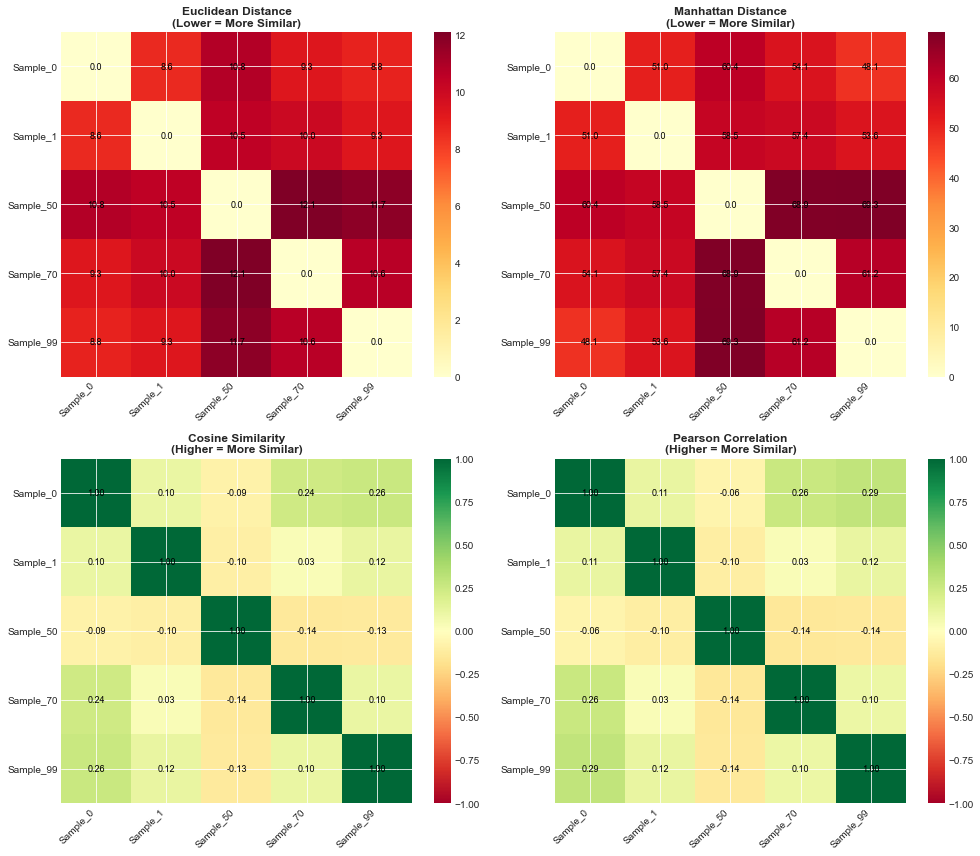

Key Observations:
1. Euclidean & Manhattan: Similar patterns (both are distances)
2. Cosine & Correlation: Similar patterns (both measure angles)
3. Distances vs Similarities: Inverse relationship
4. Diagonal: Always 0 (distance) or 1 (similarity) for self-comparison


In [14]:
# Create a more interesting dataset
np.random.seed(42)
n_samples = 100
n_features = 50

# Generate samples with different patterns
X_data = np.random.randn(n_samples, n_features)

# Pick 5 representative samples
samples_idx = [0, 1, 50, 70, 99]
X_subset = X_data[samples_idx]
sample_names = [f'Sample_{i}' for i in samples_idx]

# Calculate all pairwise distances/similarities
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

n = len(X_subset)
euclidean_mat = squareform(pdist(X_subset, metric='euclidean'))
manhattan_mat = squareform(pdist(X_subset, metric='cityblock'))
cosine_mat = 1 - squareform(pdist(X_subset, metric='cosine'))  # Convert distance to similarity
correlation_mat = np.corrcoef(X_subset)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Euclidean
im1 = axes[0, 0].imshow(euclidean_mat, cmap='YlOrRd', aspect='auto')
axes[0, 0].set_title('Euclidean Distance\n(Lower = More Similar)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(n))
axes[0, 0].set_yticks(range(n))
axes[0, 0].set_xticklabels(sample_names, rotation=45, ha='right')
axes[0, 0].set_yticklabels(sample_names)
for i in range(n):
    for j in range(n):
        axes[0, 0].text(j, i, f'{euclidean_mat[i,j]:.1f}',
                       ha='center', va='center', color='black', fontsize=9)
plt.colorbar(im1, ax=axes[0, 0])

# Manhattan
im2 = axes[0, 1].imshow(manhattan_mat, cmap='YlOrRd', aspect='auto')
axes[0, 1].set_title('Manhattan Distance\n(Lower = More Similar)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(n))
axes[0, 1].set_yticks(range(n))
axes[0, 1].set_xticklabels(sample_names, rotation=45, ha='right')
axes[0, 1].set_yticklabels(sample_names)
for i in range(n):
    for j in range(n):
        axes[0, 1].text(j, i, f'{manhattan_mat[i,j]:.1f}',
                       ha='center', va='center', color='black', fontsize=9)
plt.colorbar(im2, ax=axes[0, 1])

# Cosine similarity
im3 = axes[1, 0].imshow(cosine_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[1, 0].set_title('Cosine Similarity\n(Higher = More Similar)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(n))
axes[1, 0].set_yticks(range(n))
axes[1, 0].set_xticklabels(sample_names, rotation=45, ha='right')
axes[1, 0].set_yticklabels(sample_names)
for i in range(n):
    for j in range(n):
        axes[1, 0].text(j, i, f'{cosine_mat[i,j]:.2f}',
                       ha='center', va='center', color='black', fontsize=9)
plt.colorbar(im3, ax=axes[1, 0])

# Pearson correlation
im4 = axes[1, 1].imshow(correlation_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[1, 1].set_title('Pearson Correlation\n(Higher = More Similar)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(n))
axes[1, 1].set_yticks(range(n))
axes[1, 1].set_xticklabels(sample_names, rotation=45, ha='right')
axes[1, 1].set_yticklabels(sample_names)
for i in range(n):
    for j in range(n):
        axes[1, 1].text(j, i, f'{correlation_mat[i,j]:.2f}',
                       ha='center', va='center', color='black', fontsize=9)
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Key Observations:")
print("="*70)
print("1. Euclidean & Manhattan: Similar patterns (both are distances)")
print("2. Cosine & Correlation: Similar patterns (both measure angles)")
print("3. Distances vs Similarities: Inverse relationship")
print("4. Diagonal: Always 0 (distance) or 1 (similarity) for self-comparison")

### 1.5.5 Which Metric Should You Use?

| Metric | Use When | Pros | Cons |
|--------|----------|------|------|
| **Euclidean** | Absolute values matter | Intuitive, preserves magnitude | Sensitive to scale & outliers |
| **Manhattan** | Robust analysis needed | Less affected by outliers | Less intuitive |
| **Cosine** | Pattern matters, not magnitude | Scale-invariant | Ignores magnitude |
| **Correlation** | Linear relationships | Scale & shift invariant | Only linear relationships |

**For multi-omics:**
- **Gene expression clustering**: Pearson correlation (WGCNA)
- **Sample clustering**: Euclidean distance on standardized data
- **Differential expression**: Fold-changes + statistical tests
- **Co-expression networks**: Pearson or Spearman correlation

In [15]:
# Summary example with biological interpretation
print("Biological Example: Comparing Gene Expression Profiles")
print("="*70)
print("\nScenario: Three patients with autism-related genes")
print("\nPatient profiles:")
print(f"  A (severe ASD):      {patient_A}  <- High expression")
print(f"  B (severe ASD):      {patient_B}  <- Similar to A")
print(f"  C (moderate ASD):    {patient_C}  <- Half of A")

print("\nMetric Comparison:")
print("-" * 70)
print(f"{'Metric':<20} {'A ↔ B':<15} {'A ↔ C':<15} {'Interpretation'}")
print("-" * 70)

euc_AB = euclidean_distance(X_standardized[0], X_standardized[1])
euc_AC = euclidean_distance(X_standardized[0], X_standardized[2])
man_AB = manhattan_distance(X_standardized[0], X_standardized[1])
man_AC = manhattan_distance(X_standardized[0], X_standardized[2])
cos_AB = cosine_similarity(patient_A, patient_B)
cos_AC = cosine_similarity(patient_A, patient_C)
cor_AB = pearson_correlation(patient_A, patient_B)
cor_AC = pearson_correlation(patient_A, patient_C)

print(f"{'Euclidean (std)':<20} {euc_AB:<15.2f} {euc_AC:<15.2f} A-B very similar")
print(f"{'Manhattan (std)':<20} {man_AB:<15.2f} {man_AC:<15.2f} A-B very similar")
print(f"{'Cosine':<20} {cos_AB:<15.4f} {cos_AC:<15.4f} A-C identical pattern!")
print(f"{'Correlation':<20} {cor_AB:<15.4f} {cor_AC:<15.4f} A-C identical pattern!")

print("\nConclusion:")
print("  • Distance metrics (Euclidean, Manhattan): A and B are most similar")
print("  • Similarity metrics (Cosine, Correlation): A and C have same pattern")
print("  • Choice depends on question: magnitude or pattern?")
print("  • For gene co-expression: use correlation (WGCNA approach)")
print("  • For sample classification: use distance on standardized data")

Biological Example: Comparing Gene Expression Profiles

Scenario: Three patients with autism-related genes

Patient profiles:
  A (severe ASD):      [100 250  80 500]  <- High expression
  B (severe ASD):      [ 95 245  78 505]  <- Similar to A
  C (moderate ASD):    [ 50 120  40 250]  <- Half of A

Metric Comparison:
----------------------------------------------------------------------
Metric               A ↔ B           A ↔ C           Interpretation
----------------------------------------------------------------------
Euclidean (std)      0.26            4.33            A-B very similar
Manhattan (std)      0.46            8.66            A-B very similar
Cosine               0.9999          0.9999          A-C identical pattern!
Correlation          0.9999          0.9997          A-C identical pattern!

Conclusion:
  • Distance metrics (Euclidean, Manhattan): A and B are most similar
  • Similarity metrics (Cosine, Correlation): A and C have same pattern
  • Choice depends on q

---
# Section 2: Multi-Omics Data & ASD Dataset

Now let's explore our course dataset and understand the multi-omics data structure.

## 2.1 What is Multi-Omics?

- **Genomics**: DNA sequence - inherited, stable (genotypes/SNPs)
- **Transcriptomics**: RNA levels - dynamic, tissue-specific (gene expression)
- **Integration**: Link genotype → expression → phenotype

In [9]:
# Load our ASD multi-omics dataset
DATA_DIR = "../data/ASD_dataset/"

print("Loading ASD Multi-Omics Dataset...\n")

# Load all data files
covariates = pl.read_csv(f"{DATA_DIR}ASD_covariates.csv")
genotypes = pl.read_csv(f"{DATA_DIR}ASD_genotypes.csv")
expression = pl.read_csv(f"{DATA_DIR}ASD_expression.csv")  # Use ASD_expression.csv (100 genes)

print("Dataset Overview:")
print("="*60)
print(f"Samples: {len(covariates)} (200 ASD cases + 100 controls)")
print(f"\nData Matrices:")
print(f"  Expression: {expression.shape[0]} samples × {expression.shape[1]-1} genes")
print(f"  Genotypes:  {genotypes.shape[0]} samples × {genotypes.shape[1]-1} SNPs")
print(f"  Covariates: {covariates.shape[0]} samples × {covariates.shape[1]-1} variables")
print("="*60)

Loading ASD Multi-Omics Dataset...

Dataset Overview:
Samples: 300 (200 ASD cases + 100 controls)

Data Matrices:
  Expression: 300 samples × 100 genes
  Genotypes:  300 samples × 50 SNPs
  Covariates: 300 samples × 28 variables


In [10]:
# Preview each data type
print("\n1. EXPRESSION DATA (first 5 genes):")
print(expression.head(5).select(expression.columns[:6]))

print("\n2. GENOTYPE DATA (first 5 SNPs):")
print(genotypes.head(5).select(genotypes.columns[:6]))

print("\n3. COVARIATE DATA:")
print(covariates.head(5))


1. EXPRESSION DATA (first 5 genes):
shape: (5, 6)
┌──────────┬─────────┬───────┬────────┬───────┬───────┐
│ sample   ┆ CNTNAP2 ┆ MECP2 ┆ GRIN2B ┆ SCN2A ┆ NRXN1 │
│ ---      ┆ ---     ┆ ---   ┆ ---    ┆ ---   ┆ ---   │
│ str      ┆ i64     ┆ i64   ┆ i64    ┆ i64   ┆ i64   │
╞══════════╪═════════╪═══════╪════════╪═══════╪═══════╡
│ sample_1 ┆ 14      ┆ 207   ┆ 90     ┆ 1151  ┆ 33    │
│ sample_2 ┆ 20      ┆ 302   ┆ 162    ┆ 1961  ┆ 63    │
│ sample_3 ┆ 17      ┆ 193   ┆ 216    ┆ 1789  ┆ 39    │
│ sample_4 ┆ 4       ┆ 106   ┆ 83     ┆ 882   ┆ 9     │
│ sample_5 ┆ 3       ┆ 148   ┆ 88     ┆ 1041  ┆ 9     │
└──────────┴─────────┴───────┴────────┴───────┴───────┘

2. GENOTYPE DATA (first 5 SNPs):
shape: (5, 6)
┌──────────┬───────┬───────┬───────┬───────┬───────┐
│ sample   ┆ snp_1 ┆ snp_2 ┆ snp_3 ┆ snp_4 ┆ snp_5 │
│ ---      ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str      ┆ i64   ┆ i64   ┆ i64   ┆ i64   ┆ i64   │
╞══════════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ sample_1 ┆ 0     ┆

In [11]:
# Key genes in our dataset
gene_list = expression.columns[1:]  # Skip 'sample' column

# Some notable autism-related genes
notable_genes = ['SHANK3', 'CHD8', 'NRXN1', 'MECP2', 'CNTNAP2', 'PTEN', 'TSC1', 'NLGN3']
present_notable = [g for g in notable_genes if g in gene_list]

print(f"Total genes in dataset: {len(gene_list)}")
print(f"\nNotable autism genes present: {len(present_notable)}")
for gene in present_notable:
    print(f"  • {gene}")

Total genes in dataset: 100

Notable autism genes present: 8
  • SHANK3
  • CHD8
  • NRXN1
  • MECP2
  • CNTNAP2
  • PTEN
  • TSC1
  • NLGN3


---
## 2.2: Data Preprocessing & Quality Control

Phase 1 of any multi-omics analysis: Load, validate, and QC the data.

## 3.1 Data Loading and Sample Alignment

In [12]:
# Verify sample alignment
samples_match = (covariates['sample'].to_list() == genotypes['sample'].to_list() and 
                 genotypes['sample'].to_list() == expression['sample'].to_list())

print("SAMPLE ALIGNMENT CHECK")
print("="*60)
print(f"All datasets aligned: {samples_match}")
print(f"\nDataset shapes:")
print(f"  Covariates: {covariates.shape}")
print(f"  Genotypes:  {genotypes.shape}")
print(f"  Expression: {expression.shape}")

if samples_match:
    print("\n✓ Sample alignment verified!")
else:
    print("\n✗ WARNING: Sample mismatch detected!")

SAMPLE ALIGNMENT CHECK
All datasets aligned: True

Dataset shapes:
  Covariates: (300, 29)
  Genotypes:  (300, 51)
  Expression: (300, 101)

✓ Sample alignment verified!


## 3.2 Genotype Data QC

GENOTYPE DATA QUALITY CHECK
All values are 0/1/2: True

Minor Allele Frequency (MAF):
  Mean MAF: 0.214
  Range: 0.007 - 0.488
  SNPs with MAF < 0.05: 4


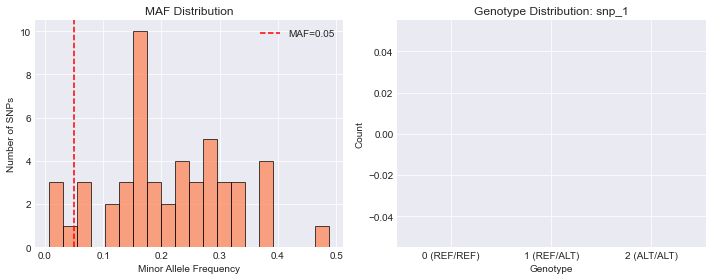

In [13]:
# Check genotype encoding (should be 0, 1, 2)
print("GENOTYPE DATA QUALITY CHECK")
print("="*60)

# Verify valid values - get genotype columns (exclude 'sample')
geno_cols = genotypes.columns[1:]

# Check if all values are in [0, 1, 2]
valid_genotypes = True
for col in geno_cols:
    col_values = genotypes[col].unique().to_list()
    if not all(v in [0, 1, 2] for v in col_values):
        valid_genotypes = False
        break

print(f"All values are 0/1/2: {valid_genotypes}")

# Calculate Minor Allele Frequency (MAF)
allele_freq = genotypes.select(geno_cols).mean().to_numpy().flatten() / 2
maf = np.minimum(allele_freq, 1 - allele_freq)

print(f"\nMinor Allele Frequency (MAF):")
print(f"  Mean MAF: {maf.mean():.3f}")
print(f"  Range: {maf.min():.3f} - {maf.max():.3f}")
print(f"  SNPs with MAF < 0.05: {(maf < 0.05).sum()}")

# Visualize MAF distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(maf, bins=20, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Minor Allele Frequency')
plt.ylabel('Number of SNPs')
plt.title('MAF Distribution')
plt.axvline(0.05, color='red', linestyle='--', label='MAF=0.05')
plt.legend()

# Example genotype distribution
plt.subplot(1, 2, 2)
snp_example = geno_cols[0]
counts_dict = genotypes[snp_example].value_counts().sort('count', descending=True).to_dict()
counts = [counts_dict.get(i, 0) for i in [0, 1, 2]]
plt.bar([0, 1, 2], counts, color=['blue', 'green', 'red'], alpha=0.7)
plt.xticks([0, 1, 2], ['0 (REF/REF)', '1 (REF/ALT)', '2 (ALT/ALT)'])
plt.xlabel('Genotype')
plt.ylabel('Count')
plt.title(f'Genotype Distribution: {snp_example}')

plt.tight_layout()
plt.show()

## 3.3 Expression Data QC

EXPRESSION DATA QUALITY CHECK
Contains negative values: False

Expression value range:
  Min: 0.00
  Max: 42755.00
  Mean: 745.53

Genes with zero variance: 0


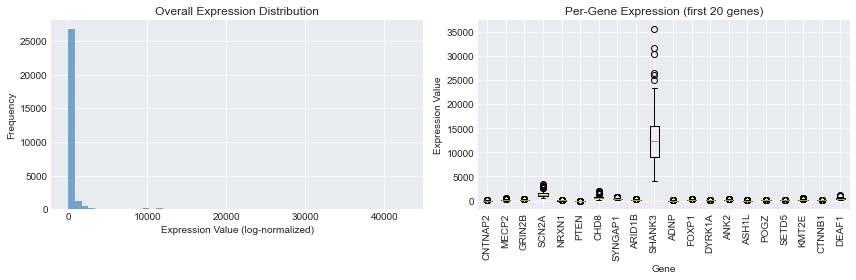

In [14]:
print("EXPRESSION DATA QUALITY CHECK")
print("="*60)

# Get expression columns (exclude 'sample')
expr_cols = expression.columns[1:]

# Check for negative values
has_negative = any((expression[col] < 0).any() for col in expr_cols)
print(f"Contains negative values: {has_negative}")

# Summary statistics
expr_values = expression.select(expr_cols).to_numpy().flatten()
print(f"\nExpression value range:")
print(f"  Min: {expr_values.min():.2f}")
print(f"  Max: {expr_values.max():.2f}")
print(f"  Mean: {expr_values.mean():.2f}")

# Check for genes with zero variance
zero_var_genes = sum(expression[col].std() == 0 for col in expr_cols)
print(f"\nGenes with zero variance: {zero_var_genes}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(expr_values, bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Expression Value (log-normalized)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Expression Distribution')

# Per-gene distributions (first 20)
first_20_genes = expr_cols[:20]
expr_data = [expression[col].to_list() for col in first_20_genes]
axes[1].boxplot(expr_data, labels=first_20_genes)
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Expression Value')
axes[1].set_title('Per-Gene Expression (first 20 genes)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 3.4 Covariate Balance Testing

In [15]:
# Separate ASD cases and controls
asd_samples = covariates.filter(pl.col('ASD') == 1)
ctrl_samples = covariates.filter(pl.col('ASD') == 0)

print("COVARIATE BALANCE: ASD vs Control")
print("="*60)

# Age comparison
age_stat, age_pval = stats.ttest_ind(ctrl_samples['Age'].to_numpy(), asd_samples['Age'].to_numpy())
print(f"\nAge:")
print(f"  Control: {ctrl_samples['Age'].mean():.1f} ± {ctrl_samples['Age'].std():.1f}")
print(f"  ASD:     {asd_samples['Age'].mean():.1f} ± {asd_samples['Age'].std():.1f}")
print(f"  p-value: {age_pval:.4f}")

# Sex comparison
sex_table = pl.DataFrame({
    'ASD': covariates['ASD'].to_list(),
    'Sex': covariates['Sex'].to_list()
}).to_pandas().pivot_table(index='ASD', columns='Sex', aggfunc='size', fill_value=0)
chi2, sex_pval, dof, expected = chi2_contingency(sex_table)
print(f"\nSex (% Male):")
print(f"  Control: {ctrl_samples['Sex'].mean()*100:.1f}%")
print(f"  ASD:     {asd_samples['Sex'].mean()*100:.1f}%")
print(f"  p-value: {sex_pval:.4f} (Chi-square)")

# IQ comparison
iq_stat, iq_pval = stats.ttest_ind(ctrl_samples['IQ'].to_numpy(), asd_samples['IQ'].to_numpy())
print(f"\nIQ:")
print(f"  Control: {ctrl_samples['IQ'].mean():.1f} ± {ctrl_samples['IQ'].std():.1f}")
print(f"  ASD:     {asd_samples['IQ'].mean():.1f} ± {asd_samples['IQ'].std():.1f}")
print(f"  p-value: {iq_pval:.4e}")

print("\n" + "="*60)
print("Note: Differences in Sex and IQ are expected in ASD cohorts")
print("These should be included as covariates in downstream analyses")

COVARIATE BALANCE: ASD vs Control

Age:
  Control: 9.0 ± 3.0
  ASD:     9.6 ± 3.2
  p-value: 0.1329

Sex (% Male):
  Control: 42.0%
  ASD:     68.5%
  p-value: 0.0000 (Chi-square)

IQ:
  Control: 101.6 ± 15.3
  ASD:     84.0 ± 23.1
  p-value: 2.5053e-11

Note: Differences in Sex and IQ are expected in ASD cohorts
These should be included as covariates in downstream analyses


## 3.5 Sample Characteristics Visualization

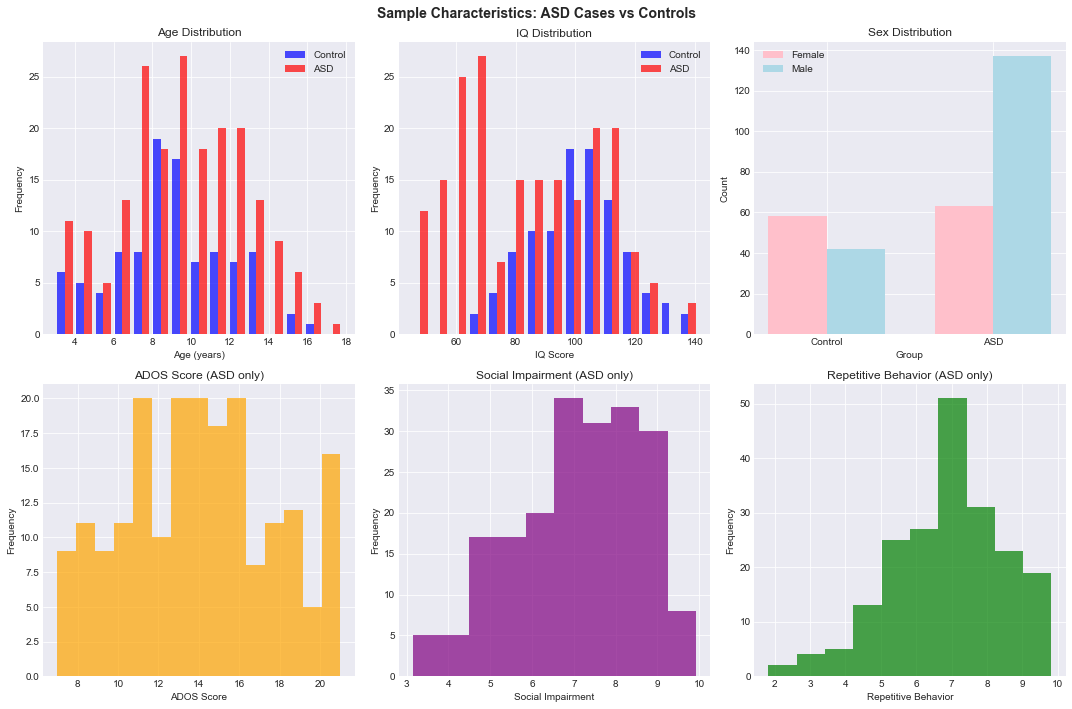

In [16]:
# 6-panel comparison plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Characteristics: ASD Cases vs Controls', fontsize=14, fontweight='bold')

# 1. Age distribution
axes[0, 0].hist([ctrl_samples['Age'].to_numpy(), asd_samples['Age'].to_numpy()], 
                bins=15, label=['Control', 'ASD'], alpha=0.7, color=['blue', 'red'])
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].legend()

# 2. IQ distribution
axes[0, 1].hist([ctrl_samples['IQ'].to_numpy(), asd_samples['IQ'].to_numpy()], 
                bins=15, label=['Control', 'ASD'], alpha=0.7, color=['blue', 'red'])
axes[0, 1].set_xlabel('IQ Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('IQ Distribution')
axes[0, 1].legend()

# 3. Sex distribution
sex_counts = covariates.group_by(['ASD', 'Sex']).count().sort(['ASD', 'Sex'])
control_female = sex_counts.filter((pl.col('ASD') == 0) & (pl.col('Sex') == 0))['count'][0] if len(sex_counts.filter((pl.col('ASD') == 0) & (pl.col('Sex') == 0))) > 0 else 0
control_male = sex_counts.filter((pl.col('ASD') == 0) & (pl.col('Sex') == 1))['count'][0] if len(sex_counts.filter((pl.col('ASD') == 0) & (pl.col('Sex') == 1))) > 0 else 0
asd_female = sex_counts.filter((pl.col('ASD') == 1) & (pl.col('Sex') == 0))['count'][0] if len(sex_counts.filter((pl.col('ASD') == 1) & (pl.col('Sex') == 0))) > 0 else 0
asd_male = sex_counts.filter((pl.col('ASD') == 1) & (pl.col('Sex') == 1))['count'][0] if len(sex_counts.filter((pl.col('ASD') == 1) & (pl.col('Sex') == 1))) > 0 else 0

x = np.arange(2)
width = 0.35
axes[0, 2].bar(x - width/2, [control_female, asd_female], width, label='Female', color='pink')
axes[0, 2].bar(x + width/2, [control_male, asd_male], width, label='Male', color='lightblue')
axes[0, 2].set_xlabel('Group')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Sex Distribution')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(['Control', 'ASD'])
axes[0, 2].legend()

# 4. ADOS Score (ASD only)
axes[1, 0].hist(asd_samples['ADOS_Score'].to_numpy(), bins=15, color='orange', alpha=0.7)
axes[1, 0].set_xlabel('ADOS Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('ADOS Score (ASD only)')

# 5. Social Impairment (ASD only)
axes[1, 1].hist(asd_samples['Social_Impairment'].to_numpy(), bins=10, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Social Impairment')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Social Impairment (ASD only)')

# 6. Repetitive Behavior (ASD only)
axes[1, 2].hist(asd_samples['Repetitive_Behavior'].to_numpy(), bins=10, color='green', alpha=0.7)
axes[1, 2].set_xlabel('Repetitive Behavior')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Repetitive Behavior (ASD only)')

plt.tight_layout()
plt.show()

## 3.6 Population Structure (PCA on Genotypes)

Performing PCA on genotype data...



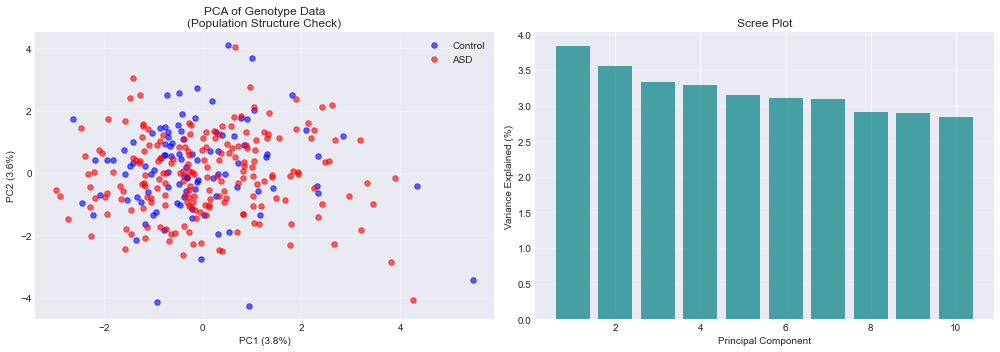

First 5 PCs explain 17.2% of variance

✓ No clear population stratification - cases and controls overlap in PC space


In [17]:
# PCA on genotype data to check population structure
print("Performing PCA on genotype data...\n")

# Get genotype columns and convert to numpy
geno_cols = genotypes.columns[1:]
geno_matrix = genotypes.select(geno_cols).to_numpy()

# Standardize genotypes
scaler = StandardScaler()
geno_scaled = scaler.fit_transform(geno_matrix)

# PCA
pca = PCA(n_components=10)
pcs = pca.fit_transform(geno_scaled)

# Create DataFrame
pc_df = pl.DataFrame({
    'sample': genotypes['sample'].to_list(),
    'PC1': pcs[:, 0],
    'PC2': pcs[:, 1],
    'PC3': pcs[:, 2],
    'PC4': pcs[:, 3],
    'PC5': pcs[:, 4],
    'ASD': covariates['ASD'].to_list()
})

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2
for status, label, color in [(0, 'Control', 'blue'), (1, 'ASD', 'red')]:
    mask_df = pc_df.filter(pl.col('ASD') == status)
    axes[0].scatter(mask_df['PC1'].to_numpy(), mask_df['PC2'].to_numpy(),
                    label=label, alpha=0.6, s=30, color=color)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA of Genotype Data\n(Population Structure Check)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scree plot
axes[1].bar(range(1, 11), pca.explained_variance_ratio_[:10] * 100, color='teal', alpha=0.7)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"First 5 PCs explain {pca.explained_variance_ratio_[:5].sum()*100:.1f}% of variance")
print("\n✓ No clear population stratification - cases and controls overlap in PC space")

## 3.7 Data Validation Summary

In [18]:
print("\n" + "="*70)
print("DATA VALIDATION SUMMARY")
print("="*70)

print("\n✓ Sample-Level Checks:")
print(f"  • All {len(covariates)} samples consistent across datasets")
print(f"  • No missing sample IDs or duplicates")
print(f"  • Sample alignment verified")

print("\n✓ Feature-Level Checks:")
print(f"  • Genotypes: {len(genotypes.columns)-1} SNPs, encoded as 0/1/2")
print(f"  • Expression: {len(expression.columns)-1} genes, log-normalized")
print(f"  • Covariates: {len(covariates.columns)-1} variables")

print("\n✓ Clinical Distribution:")
asd_count = (covariates['ASD'] == 1).sum()
ctrl_count = (covariates['ASD'] == 0).sum()
total = len(covariates)
print(f"  • Cases: {asd_count} ({asd_count/total*100:.1f}%)")
print(f"  • Controls: {ctrl_count} ({ctrl_count/total*100:.1f}%)")

print("\n" + "="*70)
print("PHASE 1 QC COMPLETE - Ready for Analysis")
print("="*70)


DATA VALIDATION SUMMARY

✓ Sample-Level Checks:
  • All 300 samples consistent across datasets
  • No missing sample IDs or duplicates
  • Sample alignment verified

✓ Feature-Level Checks:
  • Genotypes: 50 SNPs, encoded as 0/1/2
  • Expression: 100 genes, log-normalized
  • Covariates: 28 variables

✓ Clinical Distribution:
  • Cases: 200 (66.7%)
  • Controls: 100 (33.3%)

PHASE 1 QC COMPLETE - Ready for Analysis


---
# Section 3: Why multi-omics integration?

Understanding why multi-omics integration is powerful.

## 3.1 The Power of Integration

**Single-omics limitations:**
- Genomics: "SNP rs123 is associated with ASD" - but HOW?
- Transcriptomics: "Gene X is differentially expressed" - but WHY?

**Integration answers both:**
- "SNP rs123 increases Gene X expression → ASD risk"
- Now we have a mechanism!

Example: Testing if snp_1 affects CNTNAP2 expression



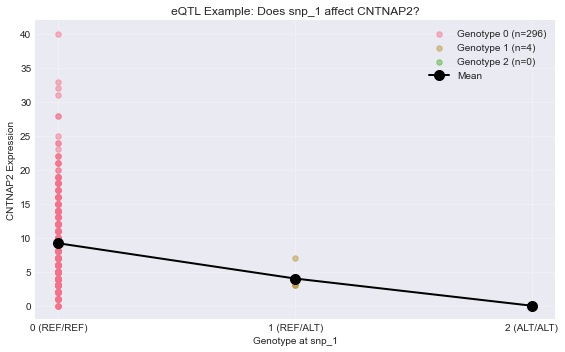

This is what eQTL analysis does systematically across all SNP-gene pairs!
We'll cover this in detail in Lesson 2.


In [19]:
# Demonstrate the concept: eQTL example
# Pick a SNP and gene to show potential relationship

snp_name = genotypes.columns[1]
gene_name = expression.columns[1]

print(f"Example: Testing if {snp_name} affects {gene_name} expression\n")

# Group expression by genotype
fig, ax = plt.subplots(figsize=(8, 5))

means = []
for geno in [0, 1, 2]:
    mask_df = genotypes.filter(pl.col(snp_name) == geno)
    sample_list = mask_df['sample'].to_list()
    expr_df = expression.filter(pl.col('sample').is_in(sample_list))
    expr_values = expr_df[gene_name].to_numpy()
    
    positions = [geno] * len(expr_values)
    ax.scatter(positions, expr_values, alpha=0.5, s=30,
               label=f'Genotype {geno} (n={len(expr_values)})')
    means.append(expr_values.mean() if len(expr_values) > 0 else 0)

# Plot means
ax.plot([0, 1, 2], means, 'k-o', markersize=10, linewidth=2, label='Mean')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 (REF/REF)', '1 (REF/ALT)', '2 (ALT/ALT)'])
ax.set_xlabel(f'Genotype at {snp_name}')
ax.set_ylabel(f'{gene_name} Expression')
ax.set_title(f'eQTL Example: Does {snp_name} affect {gene_name}?')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("This is what eQTL analysis does systematically across all SNP-gene pairs!")
print("We'll cover this in detail in Lesson 2.")

## What's Next?

| Lesson | Topic | Method |
|--------|-------|--------|
| 2 | Genetic Variation Regulation | eQTL Analysis |
| 3 | Gene Co-expression Modules | WGCNA |
| 4 | Multi-Omics Integration | MOFA2 |
| 5-8 | Machine Learning | Prediction & Interpretation |